# S2 Inter-Rater Agreement — Free-Text Questions

Measures semantic agreement between all pairs of raters (human participants + models)
on free-text VQA answers using SBERT cosine similarity.

**Three comparisons (all free-text, inst_blind):**
- **HH** Human × Human — inter-participant agreement
- **MM** Model × Model — inter-model agreement
- **HM** Human × Model — cross-group agreement

**Yes/No questions are handled separately in `10b_align_agreement_yesno.ipynb`.**

In [ ]:
# ── Ensure pair_cache is up to date before any analysis ──────────────────────
import subprocess, sys
result = subprocess.run(
    ['conda', 'run', '-n', 'zero', 'python',
     '/home/david/Desktop/yuna/HPA/analysis/build_pair_cache.py', '--no_bertscore'],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr, file=sys.stderr)

In [1]:
# ── Metric configuration ──────────────────────────────────────────────────────
# All comparisons use English answers through the same VQA normalization pipeline.
#
# EMBEDDING_MODELS: metric_name → HuggingFace model ID
#   Each model encodes all unique answers once, cached as embeddings_{name}.npz.
#   Cosine similarity is computed from stored vectors — no re-encoding per run.
#
# Model notes:
#   sbert    all-mpnet-base-v2            strong baseline, mean-pooling
#   simcse   sup-simcse-roberta-large     contrastive STS training, best for short text
#
# BERTSCORE_MODEL: separate token-level F1 — does NOT use the embedding cache.
#   roberta-large (default) or microsoft/deberta-xlarge-mnli (slower, better)

EMBEDDING_MODELS = {
    'sbert':  'sentence-transformers/all-mpnet-base-v2',
    'simcse': 'princeton-nlp/sup-simcse-roberta-large',
}
BERTSCORE_MODEL = 'roberta-large'
HF_CACHE        = '/home/david/Desktop/yuna/.cache/hf'

# METHODS drives which metrics are computed. Embedding model keys are auto-included.
METHODS = ['exact', 'jaccard', 'rouge1', 'chrf', *EMBEDDING_MODELS.keys(), 'bertscore']

In [2]:
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

BASE    = Path('/home/david/Desktop/yuna/HPA')
EXPORTS = BASE / 'analysis/session2/exports'
sys.path.insert(0, str(BASE / 'analysis'))

from utils.constants import VARIANT_ORDER, VARIANT_LABELS, VARIANT_COLORS, GROUP_COLORS

In [ ]:
# ── Load human data from nb09 export ─────────────────────────────────────────
from utils.vqa import VQAAnswerMapper
from utils.completeness import check_completeness

h_csv = pd.read_csv(EXPORTS / 'responses_human.csv')
h_csv, _h_report = check_completeness(
    h_csv, group_col='participant', question_col='question_id',
    answer_col='response', label='Human responses',
)
h_csv['answer_en'] = h_csv['response']   # compatibility alias
df           = h_csv.copy()
common_qids  = set(df['question_id'].unique())
mapper       = VQAAnswerMapper()
print(f'Human data: {df["participant"].nunique()} participants, {len(common_qids)} questions')

In [4]:
# ── Load answer_type annotation from s4 ──────────────────────────────────────
q_meta = json.load(open(BASE / 'experiment/s2_v4/s4_question.json'))
answer_type_map = {q['question_id']: q['answer_type'] for q in q_meta}

# Add to df
df['answer_type'] = df['question_id'].map(answer_type_map)

# Split common_qids by type
yesno_qids = {qid for qid in common_qids if answer_type_map.get(qid) == 'yesno'}
text_qids  = {qid for qid in common_qids if answer_type_map.get(qid) == 'text'}
print(f'common_qids: {len(common_qids)} total — {len(yesno_qids)} yesno, {len(text_qids)} free-text')


common_qids: 113 total — 25 yesno, 88 free-text


In [ ]:
# ── Load model results from nb09 export ──────────────────────────────────────
from utils.model_registry import default_all_models

m_csv = pd.read_csv(EXPORTS / 'responses_model_inst_blind.csv')
m_csv, _m_report = check_completeness(
    m_csv, group_col='model', question_col='question_id',
    answer_col='response', label='Model responses',
)

model_q_acc = {}
for label, grp in m_csv.groupby('model'):
    pivot = grp.pivot_table(index='question_id', columns='variant',
                             values='accuracy', aggfunc='mean')
    for var in VARIANT_ORDER:
        if var not in pivot.columns:
            pivot[var] = np.nan
    model_q_acc[label] = pivot[VARIANT_ORDER]

MODEL_TYPE = (m_csv[['model', 'model_group']].drop_duplicates()
              .set_index('model')['model_group'].to_dict())
ALL_MODELS = default_all_models(BASE)
MODELS     = {label: rdir / mdir for label, (rdir, mdir) in ALL_MODELS.items()}
print('Models:', list(model_q_acc.keys()))

In [6]:
# ── Compute inter-participant agreement split by answer type ──────────────────
# Lexical metrics (exact/jaccard/rouge1/chrf) are fast — computed for all types.
# SBERT excluded for yes/no (binary labels too coarse for embedding similarity).
from utils.agreement import compute_question_agreement

LEX_METHODS  = [m for m in ('exact', 'jaccard', 'rouge1', 'chrf') if m in METHODS]
TEXT_METHODS = [m for m in (*LEX_METHODS, 'sbert') if m in METHODS]

agree    = {}    # full question set
agree_tx = {}    # free-text only
agree_yn = {}    # yes/no only (lexical)

for var in VARIANT_ORDER:
    print(f'\n── Variant {var} ──')
    agree[var] = compute_question_agreement(
        df, common_qids,
        methods=TEXT_METHODS,
        answer_col='answer_en', variant=var, verbose=False,
    )
    agree_tx[var] = compute_question_agreement(
        df, text_qids,
        methods=TEXT_METHODS,
        answer_col='answer_en', variant=var, verbose=False,
    )
    agree_yn[var] = compute_question_agreement(
        df, yesno_qids,
        methods=LEX_METHODS,
        answer_col='answer_en', variant=var, verbose=False,
    )
    parts = [f'{m}={agree_tx[var][m].mean():.3f}' for m in TEXT_METHODS if m in agree_tx[var]]
    print(f'  [text  {len(text_qids):3d}q] ' + '  '.join(parts))
    yn_parts = [f'{m}={agree_yn[var][m].mean():.3f}' for m in LEX_METHODS if m in agree_yn[var]]
    print(f'  [yesno {len(yesno_qids):3d}q] ' + '  '.join(yn_parts))


── Variant C ──


/home/david/miniconda3/envs/aide/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  [text   88q] exact=0.127  jaccard=0.144  rouge1=0.152  chrf=0.189  sbert=0.510
  [yesno  25q] exact=0.573  jaccard=0.573  rouge1=0.573  chrf=0.573

── Variant B ──
  [text   88q] exact=0.117  jaccard=0.128  rouge1=0.133  chrf=0.172  sbert=0.487
  [yesno  25q] exact=0.602  jaccard=0.602  rouge1=0.602  chrf=0.602

── Variant A ──
  [text   88q] exact=0.102  jaccard=0.109  rouge1=0.113  chrf=0.154  sbert=0.469
  [yesno  25q] exact=0.555  jaccard=0.555  rouge1=0.555  chrf=0.555


/tmp/ipykernel_267913/1433733580.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
/tmp/ipykernel_267913/1433733580.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],


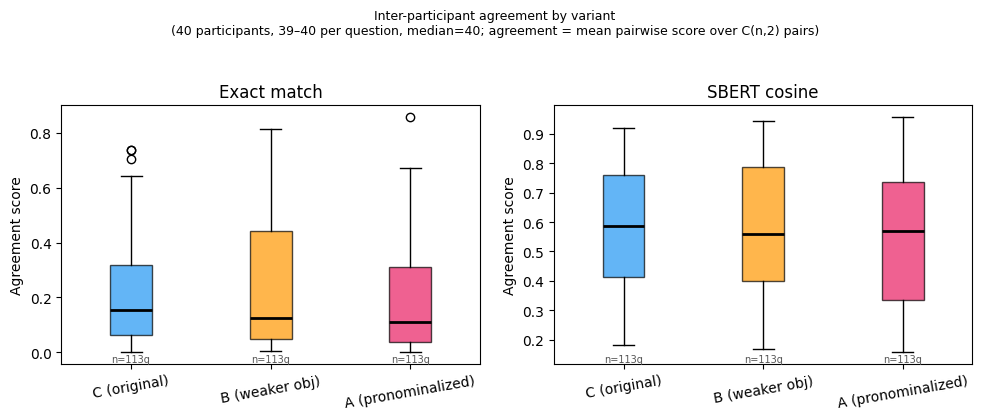

n (qids)   Mean  Median    Std    Q25    Q75
Variant Metric                                                    
C       Exact match        113  0.226   0.155  0.210  0.063  0.318
        SBERT cosine       113  0.590   0.588  0.210  0.412  0.761
B       Exact match        113  0.224   0.123  0.233  0.049  0.444
        SBERT cosine       113  0.574   0.559  0.221  0.399  0.788
A       Exact match        113  0.202   0.110  0.213  0.038  0.309
        SBERT cosine       113  0.557   0.570  0.229  0.335  0.735

In [7]:
# ── Agreement by variant — box plots ─────────────────────────────────────────
# n per question = number of participants answering that question in variant C
# Agreement score = mean pairwise [metric] over all C(n,2) pairs of participants
# Box shows distribution across all common questions (text+yesno combined)

per_q_n = df[df['variant'] == 'C'].groupby('question_id')['answer_en'].count()
n_min, n_max, n_med = int(per_q_n.min()), int(per_q_n.max()), int(per_q_n.median())

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
methods = [('exact', 'Exact match'), ('sbert', 'SBERT cosine')]
colors  = {'C': '#2196F3', 'B': '#FF9800', 'A': '#E91E63'}

for ax, (meth, title) in zip(axes, methods):
    data = [agree[var][meth].dropna().values for var in VARIANT_ORDER]
    ns   = [len(d) for d in data]
    bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
                    patch_artist=True, medianprops=dict(color='black', lw=2))
    for patch, var in zip(bp['boxes'], VARIANT_ORDER):
        patch.set_facecolor(colors[var])
        patch.set_alpha(0.7)
    ax.set_title(title)
    ax.set_ylabel('Agreement score')
    ax.tick_params(axis='x', rotation=10)
    for i, (var, n_q) in enumerate(zip(VARIANT_ORDER, ns), 1):
        ax.text(i, ax.get_ylim()[0], f'n={n_q}q', ha='center', va='bottom',
                fontsize=7, color='#555')

n_participants = df['participant'].nunique()
plt.suptitle(
    f'Inter-participant agreement by variant\n'
    f'({n_participants} participants, {n_min}–{n_max} per question, median={n_med}; '
    f'agreement = mean pairwise score over C(n,2) pairs)',
    y=1.04, fontsize=9
)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for var in VARIANT_ORDER:
    for meth, meth_label in methods:
        vals = agree[var][meth].dropna()
        rows.append({
            'Variant':  var,
            'Metric':   meth_label,
            'n (qids)': len(vals),
            'Mean':     round(vals.mean(), 3),
            'Median':   round(vals.median(), 3),
            'Std':      round(vals.std(), 3),
            'Q25':      round(vals.quantile(0.25), 3),
            'Q75':      round(vals.quantile(0.75), 3),
        })
        

summary_df = pd.DataFrame(rows).set_index(['Variant', 'Metric'])
display(summary_df)

Agreement by entity type (variant C, sorted by primary metric):
         sbert  exact  jaccard  rouge1   N
ent                                       
food     0.657  0.275    0.290   0.297  16
animal   0.627  0.248    0.263   0.270  17
place    0.622  0.286    0.289   0.291   5
object   0.593  0.216    0.226   0.230  27
product  0.565  0.136    0.155   0.162   5
person   0.563  0.230    0.244   0.250  26
vehicle  0.552  0.275    0.296   0.305   4
other    0.542  0.174    0.191   0.199   9
text     0.448  0.078    0.081   0.082   4


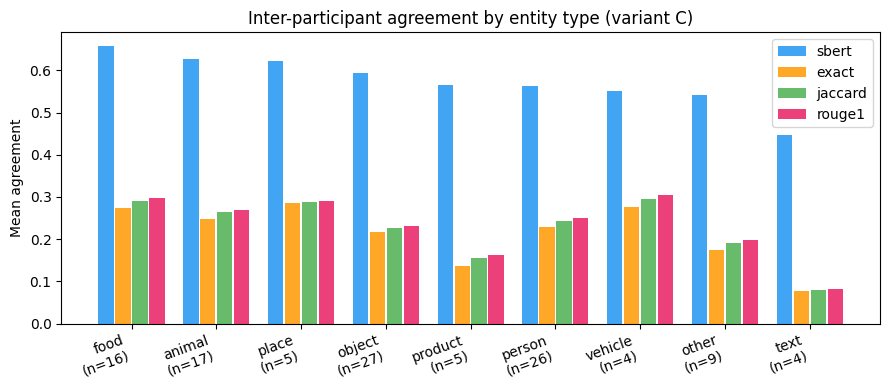

In [8]:
# ── Agreement by entity type ──────────────────────────────────────────────────
ent_map = df[['question_id', 'ent']].drop_duplicates().set_index('question_id')['ent']

# Use metrics that were computed for the full question set
plot_metrics = [m for m in ('sbert', 'exact', 'jaccard', 'rouge1') if m in agree['C'].columns]
ent_agree = agree['C'][plot_metrics].join(ent_map).groupby('ent').mean()
ent_n     = agree['C'][plot_metrics[:1]].join(ent_map).groupby('ent')[plot_metrics[0]].count().rename('N')
ent_table = ent_agree.join(ent_n).sort_values(plot_metrics[0], ascending=False)

print('Agreement by entity type (variant C, sorted by primary metric):')
print(ent_table.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(ent_table))
w = 0.8 / max(len(plot_metrics), 1)
colors_m = {'sbert': '#2196F3', 'exact': '#FF9800', 'jaccard': '#4CAF50', 'rouge1': '#E91E63'}
for k, m in enumerate(plot_metrics):
    offset = (k - len(plot_metrics) / 2 + 0.5) * w
    ax.bar(x + offset, ent_table[m], w * 0.9, label=m, alpha=0.85,
           color=colors_m.get(m, '#888'))
ax.set_xticks(x)
ax.set_xticklabels([f'{e}\n(n={ent_table.loc[e,"N"]})' for e in ent_table.index],
                   rotation=20, ha='right')
ax.set_ylabel('Mean agreement')
ax.set_title('Inter-participant agreement by entity type (variant C)')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# ── Top / bottom agreed FREE-TEXT questions (SBERT, variant C) ────────────────
# n = number of participants per question who answered in variant C
# agreement = mean pairwise SBERT cosine over all C(n,2) pairs

q_en_map = {}
for _, row in df[df['variant'] == 'C'].drop_duplicates('question_id').iterrows():
    q_en_map[row['question_id']] = row.get('question_en', str(row['question_id']))

N = 8
tx_sbert = agree_tx['C']['sbert'].dropna()

for label, ascending in [('LOWEST agreement', True), ('HIGHEST agreement', False)]:
    top = tx_sbert.sort_values(ascending=ascending).head(N)
    print(f'\n── {label} — free-text only (SBERT, variant C) ──')
    for qid, score in top.items():
        answers = df[(df.question_id == qid) & (df.variant == 'C')]['answer_en'].dropna().tolist()
        n = len(answers)
        unique  = sorted(set(answers))
        print(f'  [{score:.3f}, n={n} participants, {len(unique)} unique] {q_en_map.get(qid, qid)}')
        print(f'    answers: {unique[:6]}')


── LOWEST agreement — free-text only (SBERT, variant C) ──
  [0.183, n=40 participants, 39 unique] What kind of information does the yellow and white book look like it contains?
    answers: ['0', '4 pillars of destiny', 'anatomy information', 'book', 'cooking', 'egg']
  [0.216, n=40 participants, 35 unique] What does the man's gesture mean?
    answers: ['0', '1 more please', 'accepts', 'agreement', 'anger', 'be quiet']
  [0.217, n=40 participants, 32 unique] What does the shirt say?
    answers: ['0', '1', '3', 'adidas', 'aot', 'bac']
  [0.227, n=40 participants, 33 unique] What might a milkman have in common with the man with the backpack?
    answers: ['backpack', 'both are carrying bags', 'both are men', 'bought shares of cosmo chemical', 'carrying bag', 'carrying luggage']
  [0.228, n=40 participants, 32 unique] What does the mile say?
    answers: ['0', '10', '100', '104', '30', '40']
  [0.236, n=40 participants, 36 unique] What letter is yellow and white?
    answers: ['0', 'a

In [10]:
# ── q_en_map: question_id → English question text (variant C) ───────────────
if 'q_en_map' not in dir():
    q_en_map = {row['question_id']: row.get('question_en', str(row['question_id']))
                for _, row in df[df['variant'] == 'C'].drop_duplicates('question_id').iterrows()}


def _yn_norm(text):
    t = str(text).strip().lower()
    if t.startswith('yes'):
        return 'yes'
    if t.startswith('no'):
        return 'no'
    return t

# ── Top / bottom agreed YES/NO questions (exact match, variant C) ────────────
# For yes/no questions, exact match is used; SBERT is excluded (trivial token embeddings).
# Agreement = fraction of all C(n,2) participant pairs with identical answers.
# Sorted from least agreed (most split) → most agreed (strong consensus).

yn_sbert_excluded_note = '(SBERT excluded — binary token embeddings are uninformative)'

yn_exact = agree_yn['C']['exact'].dropna()
N = 8

for label, ascending in [('MOST SPLIT (lowest exact-match agreement)', True),
                         ('MOST CONSENSUS (highest exact-match agreement)', False)]:
    top = yn_exact.sort_values(ascending=ascending).head(N)
    print(f'\n── {label} — yes/no only (variant C) {yn_sbert_excluded_note} ──')
    for qid, score in top.items():
        answers = df[(df.question_id == qid) & (df.variant == 'C')]['answer_en'].dropna().tolist()
        n = len(answers)
        yn_answers = [_yn_norm(a) for a in answers]
        yes_n = yn_answers.count('yes')
        no_n  = yn_answers.count('no')
        other = n - yes_n - no_n
        other_str = f', {other} other' if other else ''
        print(f'  [exact={score:.3f}, n={n}] {q_en_map.get(qid, qid)}')
        print(f'    yes={yes_n}, no={no_n}{other_str}')



── MOST SPLIT (lowest exact-match agreement) — yes/no only (variant C) (SBERT excluded — binary token embeddings are uninformative) ──
  [exact=0.488, n=40] Are the elephants sleeping?
    yes=19, no=21
  [exact=0.488, n=40] Is the water in the bathtub turned on?
    yes=21, no=19
  [exact=0.488, n=40] Is there a lighthouse?
    yes=21, no=19
  [exact=0.492, n=40] Is the woman's top sleeveless?
    yes=22, no=18
  [exact=0.499, n=40] Are the cats ready to attack?
    yes=17, no=23
  [exact=0.508, n=40] Are the sheep all standing in a row?
    yes=24, no=16
  [exact=0.508, n=40] Is the girl wearing motorbike boots?
    yes=16, no=24
  [exact=0.519, n=40] Is the toilet open?
    yes=25, no=15

── MOST CONSENSUS (highest exact-match agreement) — yes/no only (variant C) (SBERT excluded — binary token embeddings are uninformative) ──
  [exact=0.738, n=40] Are these women friends?
    yes=34, no=6
  [exact=0.738, n=40] Is this car clean?
    yes=34, no=6
  [exact=0.704, n=40] Is the girl lo

In [11]:
# ── Question text lookups (en + kr) ─────────────────────────────────────────
q_meta_list = json.load(open(BASE / 'experiment/s2_v4/s4_question.json'))
q_en  = {q['question_id']: q['question_en'] for q in q_meta_list}
q_kr  = {q['question_id']: q['question_kr'] for q in q_meta_list}

# Variant-aware lookup (weaker_object / pronominalized JSONs have their own text)
_wb = json.load(open(BASE / 'experiment/s2_v4/s4_weaker_object.json'))
_pr = json.load(open(BASE / 'experiment/s2_v4/s4_pronominalized.json'))
q_en_var = {}  # (qid, var) → question_en
q_kr_var = {}
for entry, var in [(_wb, 'B'), (_pr, 'A')]:
    for q in entry:
        q_en_var[(q['question_id'], var)] = q.get('question_en', q_en.get(q['question_id'], ''))
        q_kr_var[(q['question_id'], var)] = q.get('question_kr', q_kr.get(q['question_id'], ''))
for qid in common_qids:
    q_en_var[(qid, 'C')] = q_en.get(qid, '')
    q_kr_var[(qid, 'C')] = q_kr.get(qid, '')

print(f"Question text loaded for {len(q_en)} questions")

Question text loaded for 134 questions


## HH / MM / HM Agreement — Free-Text Questions

In [ ]:
# ── Load pair_cache (built/updated by build_pair_cache.py) ───────────────────
# build_pair_cache is called automatically by all export scripts before any
# agreement figures are generated, so the parquet is always up to date.
# Run `conda run -n zero python analysis/build_pair_cache.py` manually if you
# need to refresh after adding new models or participants.

pairs_df = pd.read_parquet(EXPORTS / 'pair_cache.parquet')
print(f'\npairs_df: {len(pairs_df):,} rows | variants={pairs_df["variant"].value_counts().to_dict()}')

/tmp/ipykernel_473007/3877297829.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


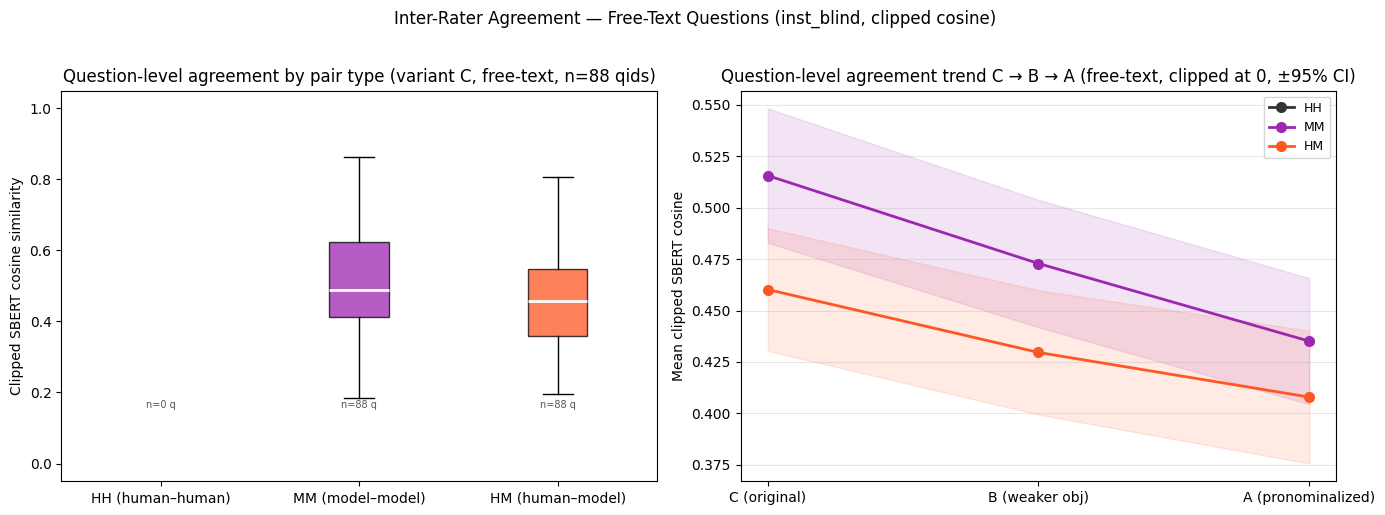

n questions   Mean  Median    Std
Variant Pair type                                   
C       HH                   0    NaN     NaN    NaN
        MM                  88  0.516   0.489  0.156
        HM                  88  0.460   0.457  0.143
B       HH                   0    NaN     NaN    NaN
        MM                  88  0.473   0.442  0.148
        HM                  88  0.430   0.425  0.145
A       HH                   0    NaN     NaN    NaN
        MM                  88  0.435   0.429  0.147
        HM                  88  0.408   0.397  0.155

In [ ]:
# ── Question-level agreement box plot: HH / MM / HM (free-text) ──────────────
from IPython.display import display

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution by pair type (variant C), one point per question
ax = axes[0]
C_q = question_pair_df[question_pair_df.variant == 'C']
data_by_type = [C_q[pt].dropna().values for pt in ['HH', 'MM', 'HM']]
colors_bt = ['#333333', '#9C27B0', '#FF5722']
bp = ax.boxplot(
    data_by_type,
    labels=['HH (human–human)', 'MM (model–model)', 'HM (human–model)'],
    patch_artist=True,
    medianprops=dict(color='white', lw=2),
)
for patch, c in zip(bp['boxes'], colors_bt):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
for i, vals in enumerate(data_by_type, 1):
    ax.text(i, ax.get_ylim()[0], f'n={len(vals):,} q', ha='center', va='bottom', fontsize=7, color='#555')
ax.set_ylabel('Clipped SBERT cosine similarity')
ax.set_title(
    f'Question-level agreement by pair type '
    f'(variant C, free-text, n={C_q["question_id"].nunique()} qids)'
)
ax.set_ylim(-0.05, 1.05)

# Right: per-variant trend for each pair type, question-level means
ax = axes[1]
x = np.arange(len(VARIANT_ORDER))
for pt, color in zip(['HH', 'MM', 'HM'], colors_bt):
    means = [question_pair_df[question_pair_df.variant == v][pt].mean() for v in VARIANT_ORDER]
    sems = [question_pair_df[question_pair_df.variant == v][pt].dropna().sem() for v in VARIANT_ORDER]
    ax.plot(x, means, 'o-', color=color, label=pt, lw=2, ms=7)
    ax.fill_between(
        x,
        np.array(means) - 1.96 * np.array(sems),
        np.array(means) + 1.96 * np.array(sems),
        color=color,
        alpha=0.12,
    )
ax.set_xticks(x)
ax.set_xticklabels(['C (original)', 'B (weaker obj)', 'A (pronominalized)'])
ax.set_ylabel('Mean clipped SBERT cosine')
ax.set_title('Question-level agreement trend C → B → A (free-text, clipped at 0, ±95% CI)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Inter-Rater Agreement — Free-Text Questions (inst_blind, clipped cosine)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
tbl_rows = []
for var in VARIANT_ORDER:
    sub = question_pair_df[question_pair_df.variant == var]
    for pt in ['HH', 'MM', 'HM']:
        vals = sub[pt].dropna()
        tbl_rows.append({
            'Variant': var,
            'Pair type': pt,
            'n questions': len(vals),
            'Mean': round(vals.mean(), 3),
            'Median': round(vals.median(), 3),
            'Std': round(vals.std(), 3),
        })
display(pd.DataFrame(tbl_rows).set_index(['Variant', 'Pair type']))


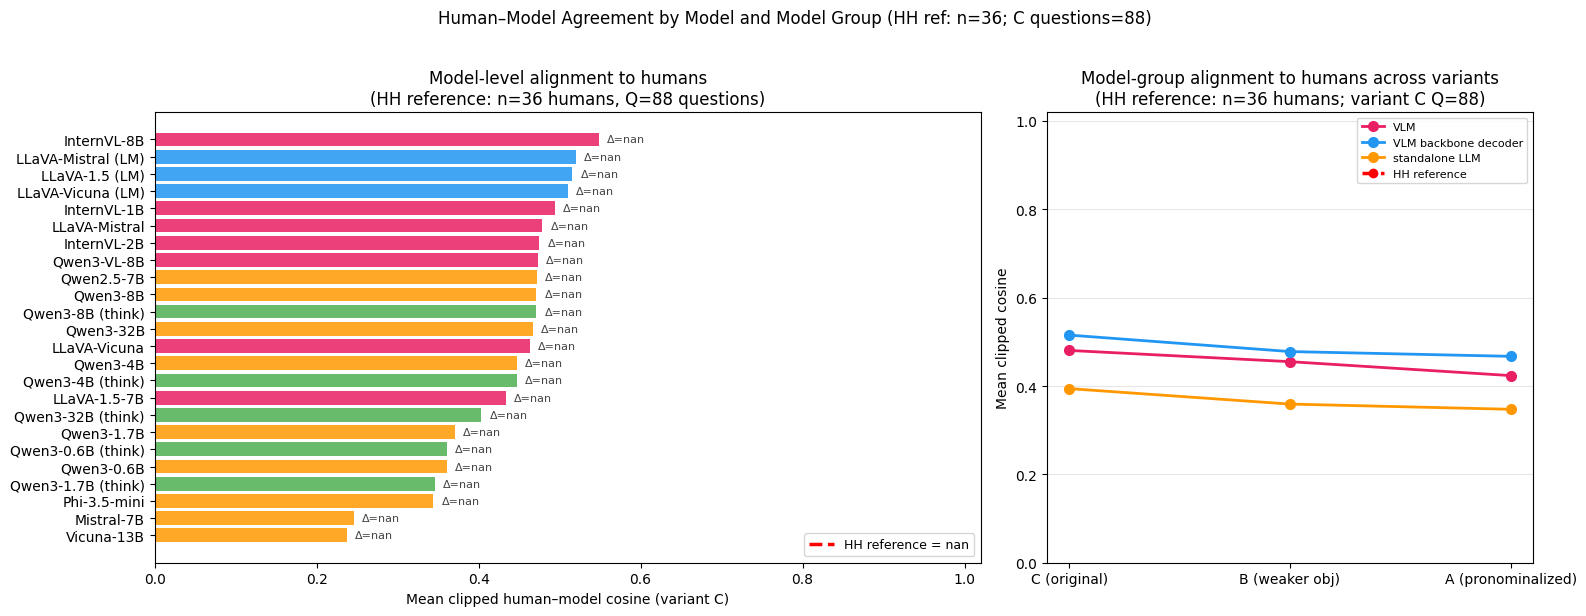

,model,model_group,hm_mean,hh_mean,gap_to_hh,n_questions
50,InternVL-8B,VLM,0.548,NaN,NaN,88
54,LLaVA-Mistral (LM),VLM backbone decoder,0.520,NaN,NaN,88
51,LLaVA-1.5 (LM),VLM backbone decoder,0.516,NaN,NaN,88
56,LLaVA-Vicuna (LM),VLM backbone decoder,0.510,NaN,NaN,88
48,InternVL-1B,VLM,0.495,NaN,NaN,87
53,LLaVA-Mistral,VLM,0.479,NaN,NaN,88
49,InternVL-2B,VLM,0.475,NaN,NaN,88
70,Qwen3-VL-8B,VLM,0.474,NaN,NaN,87
59,Qwen2.5-7B,standalone LLM,0.472,NaN,NaN,88
69,Qwen3-8B (think),standalone LLM (think),0.471,NaN,NaN,88


,variant,model_group,hm_mean,hh_mean,gap_to_hh,n_questions
1,A,VLM backbone decoder,0.467,NaN,NaN,87
0,A,VLM,0.424,NaN,NaN,88
3,A,standalone LLM (think),0.366,NaN,NaN,88
2,A,standalone LLM,0.347,NaN,NaN,88
5,B,VLM backbone decoder,0.478,NaN,NaN,88
4,B,VLM,0.455,NaN,NaN,88
7,B,standalone LLM (think),0.376,NaN,NaN,88
6,B,standalone LLM,0.359,NaN,NaN,88
9,C,VLM backbone decoder,0.515,NaN,NaN,88
8,C,VLM,0.481,NaN,NaN,88


In [ ]:
# ── Human–Model agreement by model and model group (HH reference in red) ─────
# One point per question for each model: mean clipped cosine between that model
# and all available human answers for the same (question_id, variant).

hm_pairs = pairs_df[pairs_df['pair_type'] == 'HM'].copy()

# In cell 15, HM pairs are normalized so subject_1 is human and subject_2 is model.
model_question_df = (
    hm_pairs.groupby(['variant', 'question_id', 'subject_2'])['sbert_score_clip']
    .mean()
    .rename('HM_model')
    .reset_index()
    .rename(columns={'subject_2': 'model'})
)
model_question_df['model_group'] = model_question_df['model'].map(rater_group)

model_summary_df = (
    model_question_df.groupby(['variant', 'model', 'model_group'])['HM_model']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'hm_mean', 'median': 'hm_median', 'std': 'hm_std', 'count': 'n_questions'})
)

hh_ref_df = (
    question_pair_df.groupby('variant')['HH']
    .mean()
    .rename('hh_mean')
    .reset_index()
)
model_summary_df = model_summary_df.merge(hh_ref_df, on='variant', how='left')
model_summary_df['gap_to_hh'] = model_summary_df['hh_mean'] - model_summary_df['hm_mean']

# Group-level summary: average question-level HM by model group.
group_question_df = (
    model_question_df.groupby(['variant', 'question_id', 'model_group'])['HM_model']
    .mean()
    .rename('HM_group')
    .reset_index()
)
group_summary_df = (
    group_question_df.groupby(['variant', 'model_group'])['HM_group']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'hm_mean', 'median': 'hm_median', 'std': 'hm_std', 'count': 'n_questions'})
)
group_summary_df = group_summary_df.merge(hh_ref_df, on='variant', how='left')
group_summary_df['gap_to_hh'] = group_summary_df['hh_mean'] - group_summary_df['hm_mean']

n_humans_ref = len(human_raters)
n_questions_c = int(model_question_df[model_question_df['variant'] == 'C']['question_id'].nunique())

C_models = model_summary_df[model_summary_df['variant'] == 'C'].sort_values('hm_mean')
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.7, 1.0]})

# Left: model-level agreement in variant C with HH reference.
ax = axes[0]
bar_colors = [GROUP_COLORS.get(g, '#888888') for g in C_models['model_group']]
ax.barh(C_models['model'], C_models['hm_mean'], color=bar_colors, alpha=0.85)
hh_c = float(hh_ref_df.loc[hh_ref_df['variant'] == 'C', 'hh_mean'].iloc[0])
ax.axvline(hh_c, color='red', lw=2.5, ls='--', label=f'HH reference = {hh_c:.3f}')
for y, (_, row) in enumerate(C_models.iterrows()):
    ax.text(row['hm_mean'] + 0.01, y, f"Δ={row['gap_to_hh']:.3f}", va='center', fontsize=8, color='#444')
ax.set_xlabel('Mean clipped human–model cosine (variant C)')
ax.set_title(f'Model-level alignment to humans\n(HH reference: n={n_humans_ref} humans, Q={n_questions_c} questions)')
ax.set_xlim(0, 1.02)
ax.legend(loc='lower right', fontsize=9)

# Right: group trend across variants with HH reference.
ax = axes[1]
for group in ['VLM', 'VLM backbone decoder', 'standalone LLM']:
    sub = group_summary_df[group_summary_df['model_group'] == group]
    if sub.empty:
        continue
    sub = sub.set_index('variant').reindex(VARIANT_ORDER).reset_index()
    ax.plot(
        np.arange(len(VARIANT_ORDER)),
        sub['hm_mean'],
        marker='o',
        lw=2,
        ms=7,
        color=GROUP_COLORS.get(group, '#888888'),
        label=group,
    )

hh_line = hh_ref_df.set_index('variant').reindex(VARIANT_ORDER)['hh_mean'].to_numpy()
ax.plot(
    np.arange(len(VARIANT_ORDER)),
    hh_line,
    color='red',
    lw=2.5,
    ls='--',
    marker='o',
    ms=6,
    label='HH reference',
)
ax.set_xticks(np.arange(len(VARIANT_ORDER)))
ax.set_xticklabels([VARIANT_LABELS[v] for v in VARIANT_ORDER])
ax.set_ylim(0, 1.02)
ax.set_ylabel('Mean clipped cosine')
ax.set_title(f'Model-group alignment to humans across variants\n(HH reference: n={n_humans_ref} humans; variant C Q={n_questions_c})')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8)

plt.suptitle(f'Human–Model Agreement by Model and Model Group (HH ref: n={n_humans_ref}; C questions={n_questions_c})', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

display(
    model_summary_df[model_summary_df['variant'] == 'C'][['model', 'model_group', 'hm_mean', 'hh_mean', 'gap_to_hh', 'n_questions']]
    .sort_values('hm_mean', ascending=False)
    .round(3)
)

display(
    group_summary_df[['variant', 'model_group', 'hm_mean', 'hh_mean', 'gap_to_hh', 'n_questions']]
    .sort_values(['variant', 'hm_mean'], ascending=[True, False])
    .round(3)
)


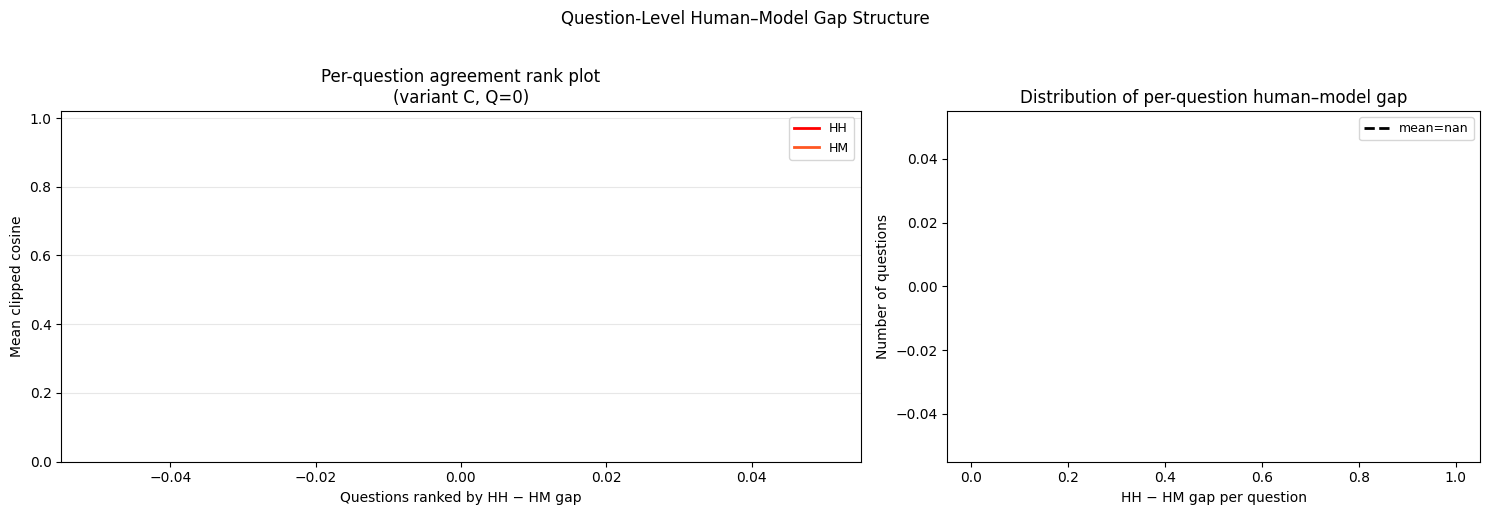

,question_en,HH,HM,MM,gap_HH_HM


In [ ]:
# ── Top/bottom questions by HH agreement (variant C) ─────────────────────────
# Companion table to the rank plot in the next cell.
from IPython.display import display

rank_df = (
    question_pair_df[question_pair_df['variant'] == 'C'][['question_id', 'question_en', 'HH', 'HM', 'MM']]
    .dropna(subset=['HH', 'HM'])
    .sort_values('HH', ascending=False)
    .reset_index(drop=True)
)

print(f'── Top 10 questions (highest HH — easiest, n={len(rank_df)}) ──')
display(rank_df[['question_en', 'HH', 'MM', 'HM']].head(10).round(3))

print('\n── Bottom 10 questions (lowest HH — hardest) ──')
display(rank_df[['question_en', 'HH', 'MM', 'HM']].tail(10).round(3))


/tmp/ipykernel_473007/4073987446.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


NameError: name 'TIER_ORDER' is not defined

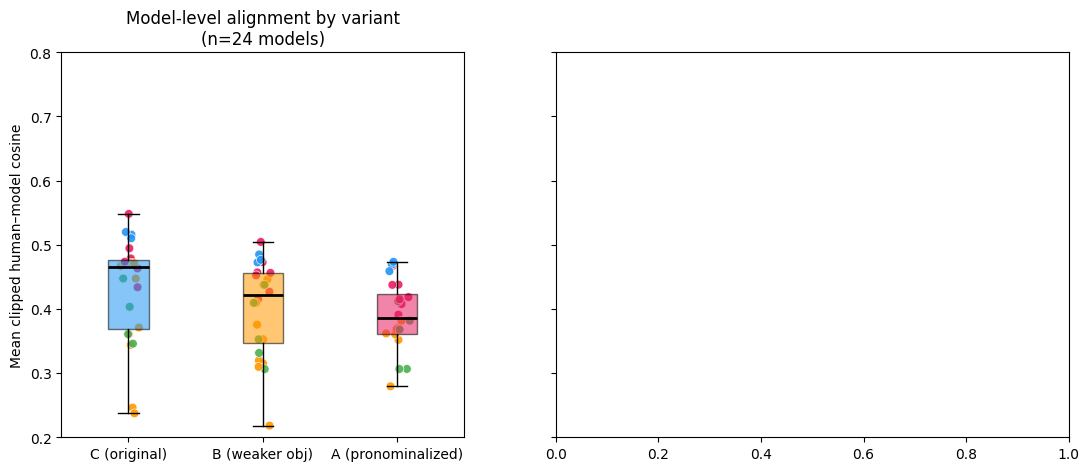

In [ ]:
# ── Variant-separated model alignment distribution ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1.1, 1.4]}, sharey=True)

# Left: model-level distribution within each variant
ax = axes[0]
box_data = [
    model_summary_df[model_summary_df['variant'] == var]['hm_mean'].dropna().values
    for var in VARIANT_ORDER
]
bp = ax.boxplot(
    box_data,
    labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
)
for patch, var in zip(bp['boxes'], VARIANT_ORDER):
    patch.set_facecolor(VARIANT_COLORS[var])
    patch.set_alpha(0.55)
for i, var in enumerate(VARIANT_ORDER, 1):
    sub = model_summary_df[model_summary_df['variant'] == var]
    x = np.random.normal(i, 0.04, size=len(sub))
    colors = [GROUP_COLORS.get(g, '#888888') for g in sub['model_group']]
    ax.scatter(x, sub['hm_mean'], c=colors, s=40, alpha=0.9, edgecolor='white', linewidth=0.5)
    hh_var = float(hh_ref_df.loc[hh_ref_df['variant'] == var, 'hh_mean'].iloc[0])
    ax.hlines(hh_var, i - 0.28, i + 0.28, colors='red', linestyles='--', lw=2)
    # ax.text(i, 0.4, f'n={len(sub)} models', ha='center', va='bottom', fontsize=8, color='#555')
ax.set_ylabel('Mean clipped human–model cosine')
ax.set_title(f'Model-level alignment by variant\n(n={len(sub)} models)') # red dash = HH reference per variant)')
ax.set_ylim(0.2, 0.8)

# Right: grouped bars by model group across variants
ax = axes[1]
groups = list(TIER_ORDER)
x = np.arange(len(VARIANT_ORDER))
width = 0.22
for j, group in enumerate(groups):
    sub = group_summary_df[group_summary_df['model_group'] == group].set_index('variant').reindex(VARIANT_ORDER)
    vals = sub['hm_mean'].to_numpy()
    ax.bar(
        x + (j - 1) * width,
        vals,
        width=width,
        color=GROUP_COLORS.get(group, '#888888'),
        alpha=0.8,
        label=group,
    )
    for xi, yi in zip(x + (j - 1) * width, vals):
        if not np.isnan(yi):
            ax.text(xi, yi + 0.01, f'{yi:.2f}', ha='center', va='bottom', fontsize=7, rotation=90)
for i, var in enumerate(VARIANT_ORDER):
    hh_var = float(hh_ref_df.loc[hh_ref_df['variant'] == var, 'hh_mean'].iloc[0])
    ax.hlines(hh_var, i - 0.4, i + 0.4, colors='red', linestyles='--', lw=2)
ax.set_xticks(x)
ax.set_xticklabels([VARIANT_LABELS[v] for v in VARIANT_ORDER])
ax.set_ylim(0.3, 0.6)
ax.set_ylabel('Mean clipped human–model cosine')
ax.set_title('Model-group means by variant\n(red dash = HH reference)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    f'Variant-Separated Human–Model Alignment (n_humans={n_humans_ref}; questions={n_questions_c})',
    y=1.02,
    fontsize=12,
)
plt.tight_layout()
plt.show()

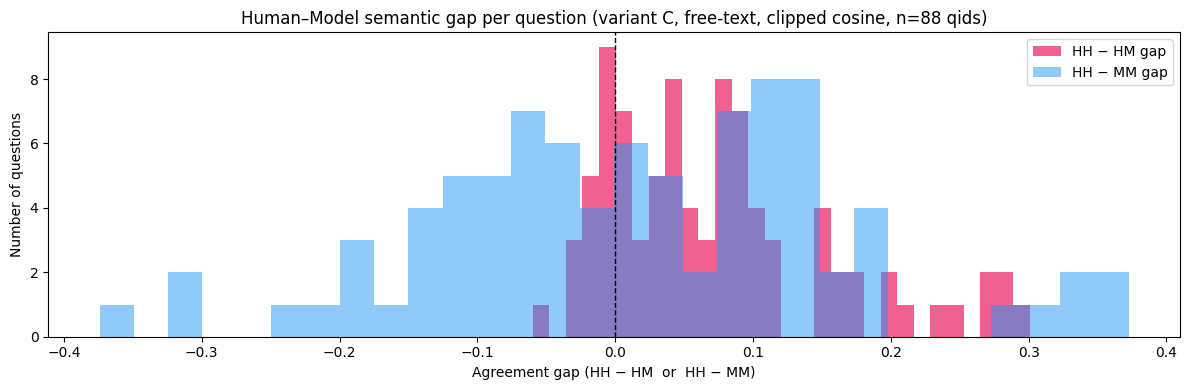

Mean HH−HM gap: 0.073  (positive = humans agree more with each other than with models)
Mean HH−MM gap: 0.018

── Top 8 questions with LARGEST human–model gap ──


,question_en,HH,MM,HM,gap_HM,n_humans,n_models
55,How many of these people are female?,0.717,0.410,0.416,0.301,36,22
56,How many bottles of water are on the table?,0.804,0.471,0.517,0.287,36,21
71,How many train track are there?,0.747,0.375,0.470,0.278,36,22
3,How many benches are in the background?,0.732,0.374,0.464,0.269,36,23
18,How many kids have glasses?,0.639,0.311,0.373,0.266,36,21
84,How many empty chairs are there?,0.665,0.388,0.414,0.252,36,22
49,How many bagels are here?,0.697,0.504,0.463,0.233,36,22
22,How many cranes are in this image?,0.703,0.587,0.496,0.207,36,23



── Top 8 questions with SMALLEST human–model gap (most aligned) ──


,question_en,HH,MM,HM,gap_HM,n_humans,n_models
39,What might a milkman have in common with the m...,0.228,0.340,0.248,-0.020,36,21
58,What color of wine is in the glasses?,0.720,0.803,0.740,-0.020,36,22
26,What is the name of the store closest to the van?,0.267,0.474,0.287,-0.020,36,22
76,What kind of alcohol is in the glasses?,0.408,0.542,0.432,-0.024,36,21
17,Where are the cows?,0.353,0.532,0.378,-0.025,36,21
32,Where is the salad?,0.375,0.450,0.402,-0.027,36,22
81,Why is the man wearing protective gear?,0.283,0.480,0.317,-0.033,36,23
2,What type of computer is the cat using?,0.444,0.686,0.504,-0.060,36,23


In [ ]:
# ── Per-question HH / MM / HM comparison (variant C, free-text) ───────────────
# Each question is a point. Axes: HH (x) vs HM (y), with MM shown as a third series.
# Questions above the diagonal: models align better than humans with each other.
# Questions below: humans align more with each other than models do with them.

cmp_df = question_pair_df[question_pair_df.variant == 'C'].copy()
cmp_df = cmp_df[['question_id', 'question_en', 'HH', 'MM', 'HM']].dropna(subset=['HH', 'HM'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: scatter HH vs HM, MM vs HM per question ────────────────────────────
ax = axes[0]
ax.scatter(cmp_df['HH'], cmp_df['HM'], s=28, alpha=0.6, color='#333333', label='HH vs HM', zorder=3)
if cmp_df['MM'].notna().any():
    ax.scatter(cmp_df['MM'], cmp_df['HM'], s=28, alpha=0.5, color='#9C27B0',
               label='MM vs HM', marker='^', zorder=3)
lims = [min(cmp_df[['HH','MM','HM']].min()), max(cmp_df[['HH','MM','HM']].max())]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.5, label='x = y (equal agreement)')
ax.set_xlabel('HH or MM agreement (clipped SBERT)')
ax.set_ylabel('HM agreement (clipped SBERT)')
ax.set_title(f'Per-question agreement: HH/MM vs HM\n(variant C, n={len(cmp_df)} questions)')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# ── Right: sorted question rank — HH / MM / HM as three lines ────────────────
ax = axes[1]
rank_df = cmp_df.sort_values('HH', ascending=False).reset_index(drop=True)
rank_df['rank'] = np.arange(1, len(rank_df) + 1)
ax.plot(rank_df['rank'], rank_df['HH'], color='#333333', lw=2,   label='HH (human–human)')
ax.plot(rank_df['rank'], rank_df['HM'], color='#FF5722', lw=2,   label='HM (human–model)')
if rank_df['MM'].notna().any():
    ax.plot(rank_df['rank'], rank_df['MM'], color='#9C27B0', lw=1.5, alpha=0.8,
            label='MM (model–model)')
ax.fill_between(rank_df['rank'], rank_df['HM'], rank_df['HH'],
                color='#FFCDD2', alpha=0.4, label='HH − HM region')
ax.set_xlabel('Questions ranked by HH agreement')
ax.set_ylabel('Agreement score')
ax.set_title('HH / MM / HM per question (ranked by HH, variant C)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.02)

plt.suptitle('Human–human vs Human–model vs Model–model Agreement (free-text, clipped SBERT)',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Summary table
print(f"Mean  HH={cmp_df['HH'].mean():.3f}  MM={cmp_df['MM'].mean():.3f}  HM={cmp_df['HM'].mean():.3f}")
print(f"Median HH={cmp_df['HH'].median():.3f}  MM={cmp_df['MM'].median():.3f}  HM={cmp_df['HM'].median():.3f}")

print('\n── Top 8 questions: HM closest to HH (most human-aligned models) ──')
top = cmp_df.assign(diff=lambda d: (d['HH'] - d['HM']).abs()).sort_values('diff')
from IPython.display import display
display(top[['question_en', 'HH', 'MM', 'HM']].head(8).round(3))

print('\n── Top 8 questions: HM furthest from HH (least human-aligned models) ──')
display(top[['question_en', 'HH', 'MM', 'HM']].tail(8).round(3))


NameError: name 'pairs_df' is not defined

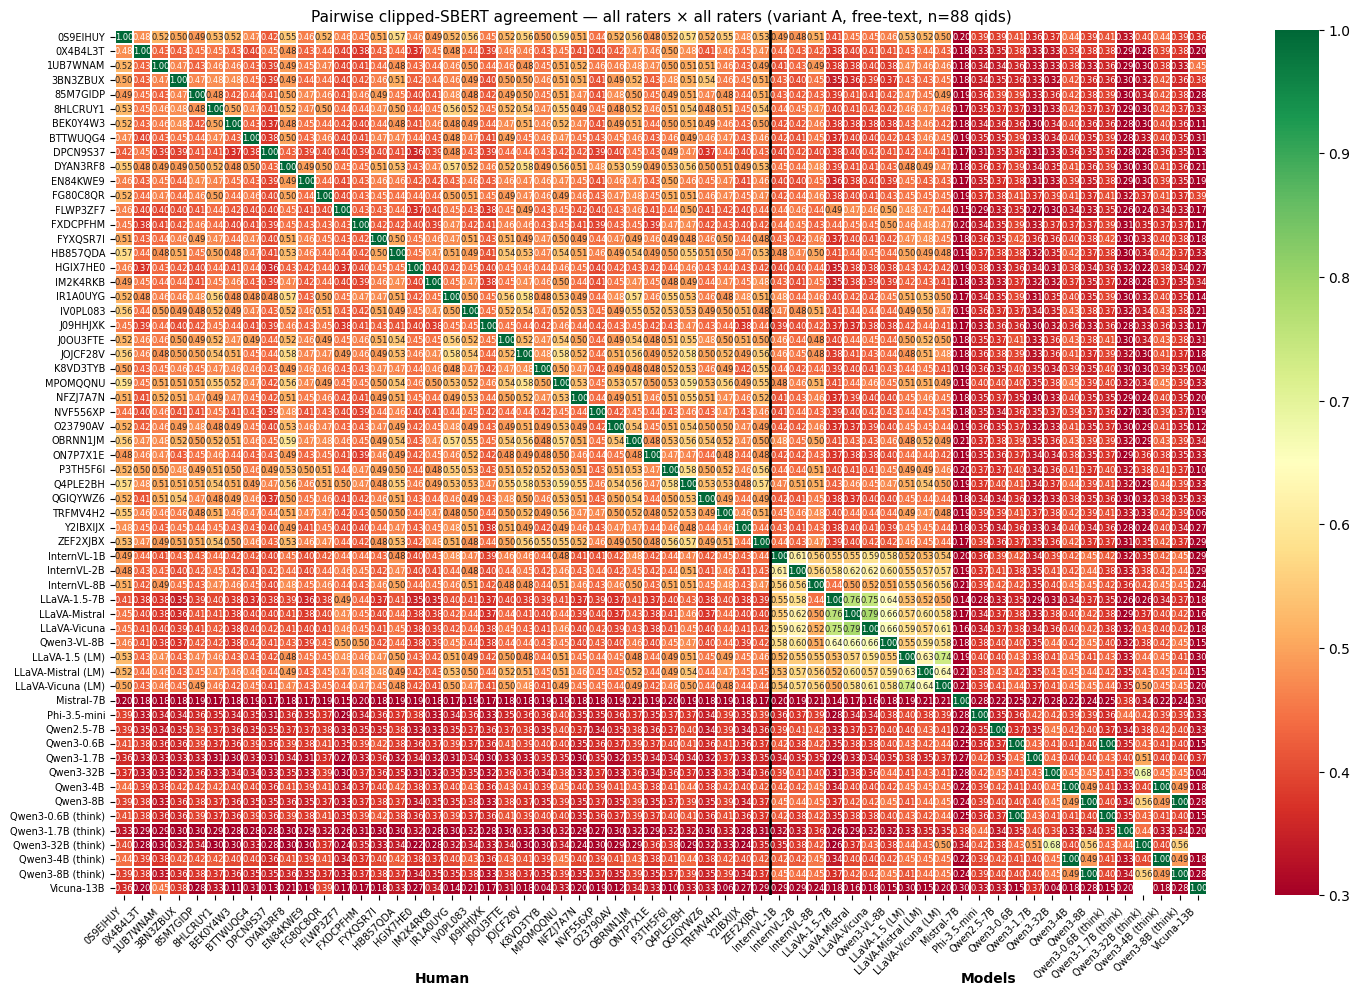

In [ ]:
# ── Full pairwise agreement heatmap (all raters × all raters, variant C) ──────
# Mean SBERT cosine across all free-text questions, variant C
variant = "A" 
pair_mean = (pairs_df[pairs_df.variant == variant]
             .groupby(['subject_1', 'subject_2'])['sbert_score_clip'].mean())

rater_order = human_raters + model_raters
n = len(rater_order)
heat = pd.DataFrame(np.nan, index=rater_order, columns=rater_order)

for r1, r2 in combinations(rater_order, 2):
    val = pair_mean.get((r1, r2), pair_mean.get((r2, r1), np.nan))
    heat.loc[r1, r2] = val
    heat.loc[r2, r1] = val
heat_arr = heat.to_numpy(copy=True)
np.fill_diagonal(heat_arr, 1.0)
heat = pd.DataFrame(heat_arr, index=rater_order, columns=rater_order)

fig, ax = plt.subplots(figsize=(15, 10))
import seaborn as sns
sns.heatmap(
    heat,
    ax=ax,
    cmap='RdYlGn',
    vmin=0.3,
    vmax=1.0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 6},
    linewidths=0.3,
    linecolor='white',
    xticklabels=rater_order,
    yticklabels=rater_order,
)

n_h = len(human_raters)
for pos in [n_h]:
    ax.axhline(pos, color='black', lw=2)
    ax.axvline(pos, color='black', lw=2)

ax.text(n_h / 2, -0.1, 'Human', ha='center', fontsize=10, fontweight='bold', transform=ax.get_xaxis_transform())
ax.text((n_h + n) / 2, -0.1, 'Models', ha='center', fontsize=10, fontweight='bold', transform=ax.get_xaxis_transform())

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
ax.set_title(
    f'Pairwise clipped-SBERT agreement — all raters × all raters '
    f'(variant {variant}, free-text, n={question_pair_df[question_pair_df.variant == variant]["question_id"].nunique()} qids)',
    fontsize=11,
)
plt.tight_layout(); plt.show()


In [ ]:
# ── Rebuild notebook helpers from pairs_df ────────────────────────────────────
# pairs_df already contains the saved pair_cache. Reconstruct the variables
# that downstream visualization cells expect.

from itertools import combinations

# Rater group lookup (human vs model group name)
rater_group = {}
for _, row in pairs_df[pairs_df['pair_type'] == 'HH'][['subject_1', 'subject_group_1']].drop_duplicates().iterrows():
    rater_group[row['subject_1']] = row['subject_group_1']
for _, row in pairs_df[pairs_df['pair_type'] == 'HM'][['subject_1', 'subject_group_1',
                                                         'subject_2', 'subject_group_2']].drop_duplicates().iterrows():
    rater_group[row['subject_1']] = row['subject_group_1']
    rater_group[row['subject_2']] = row['subject_group_2']
for _, row in pairs_df[pairs_df['pair_type'] == 'MM'][['subject_1', 'subject_group_1',
                                                         'subject_2', 'subject_group_2']].drop_duplicates().iterrows():
    rater_group[row['subject_1']] = row['subject_group_1']
    rater_group[row['subject_2']] = row['subject_group_2']

human_raters = sorted({s for s, g in rater_group.items() if g == 'human'})
model_raters = sorted({s for s, g in rater_group.items() if g != 'human'})
all_raters   = human_raters + model_raters
print(f'Raters: {len(human_raters)} humans + {len(model_raters)} models')

# Rebuild question_pair_df (per-question aggregated scores by pair type)
_score_cols = [c for c in pairs_df.columns
               if c.endswith('_score') or c.endswith('_clip') or c == 'bertscore_f1']

def _rebuild_question_pair_df(df):
    rows = []
    for (qid, var), grp in df.groupby(['question_id', 'variant'], sort=False):
        row = {
            'question_id': qid,
            'question_en': grp['question_en'].iloc[0],
            'question_kr': grp['question_kr'].iloc[0] if 'question_kr' in grp.columns else '',
            'variant':     var,
            'ent':         grp['ent'].iloc[0] if 'ent' in grp.columns else '',
            'op':          grp['op'].iloc[0]  if 'op'  in grp.columns else '',
        }
        for pt in ('HH', 'MM', 'HM'):
            pt_grp = grp[grp['pair_type'] == pt]
            row[f'n_pairs_{pt}'] = len(pt_grp)
            for sc in _score_cols:
                if sc in pt_grp.columns:
                    row[f'{pt}_{sc}'] = pt_grp[sc].mean()
        rows.append(row)
    return pd.DataFrame(rows)

question_pair_df = _rebuild_question_pair_df(pairs_df)

# HH / MM / HM convenience aliases → primary metric (sbert_score_clip)
for _cand in ('sbert_score_clip', 'sbert_score', 'simcse_score_clip', 'simcse_score'):
    if f'HH_{_cand}' in question_pair_df.columns:
        for _pt in ('HH', 'MM', 'HM'):
            question_pair_df[_pt] = question_pair_df[f'{_pt}_{_cand}']
        break

n_variants = question_pair_df['variant'].value_counts().to_dict()
print(f'question_pair_df: {len(question_pair_df)} rows — {n_variants}')

# Summary
C_pairs = pairs_df[pairs_df['variant'] == 'C']
print('\nMean scores by pair type (variant C):')
for col in _score_cols:
    row = C_pairs.groupby('pair_type')[col].mean().reindex(['HH', 'MM', 'HM'])
    print(f'  {col:25s}  HH={row.get("HH", float("nan")):.3f}  '
          f'MM={row.get("MM", float("nan")):.3f}  HM={row.get("HM", float("nan")):.3f}')